# Test interactif — DLBAC Amazon (`nouveau_module`)

Pipeline **aligné sur les baselines sklearn** (notebook `amazon_classical_baselines`) :

1. **One-hot DLBAC complet** (~14k colonnes, cache disque) ;
2. **Phase 1** : classification, early stop **AUROC**, sans focal/sampler ;
3. **Phase 2** : contrefactuels légers (reprise des poids) ;
4. Comparaison **LinearSVM** + HistGB sur les mêmes features.

**CUDA** si disponible. Prérequis : `DlbacAlpha-main/dataset/real-world/amazon1/`.

In [11]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Racine HyConEx_from_scratch
_cwd = Path.cwd().resolve()
ROOT = None
for p in (_cwd, _cwd.parent):
    if (p / "train_nouveau_module_dlbac_amazon_quantile.py").is_file():
        ROOT = p
        break
if ROOT is None:
    raise FileNotFoundError(
        "train_nouveau_module_dlbac_amazon_quantile.py introuvable. "
        "Lancez Jupyter depuis notebooks/ ou HyConEx_from_scratch/."
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Recharger les sous-modules (evite ImportError apres modification du code)
for _mod in (
    "nouveau_module.sklearn_baseline",
    "nouveau_module.binary_metrics",
    "nouveau_module.trainer",
    "nouveau_module",
    "train_nouveau_module_dlbac_quantile",
    "train_nouveau_module_dlbac_amazon_quantile",
):
    if _mod in sys.modules:
        importlib.reload(sys.modules[_mod])

import train_nouveau_module_dlbac_amazon_quantile as amazon_pipe
importlib.reload(amazon_pipe)

from prepare_dlbac_datasets import explain_counterfactual_flip, format_rule
from train_nouveau_module_dlbac_amazon_quantile import (
    AMAZON_NAMES,
    discover_amazon_specs,
    train_amazon,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RESULTS_DIR = ROOT / "results" / "nouveau_module_dlbac_amazon"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# CUDA si disponible, sinon CPU (passe aussi au HybridDRTrainer)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}")
print(f"Device choisi : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
else:
    print("CUDA non disponible — entraînement sur CPU (plus lent sur Amazon one-hot).")

PyTorch 2.5.1+cu121
Device choisi : cuda
GPU : NVIDIA GeForce 940MX


## Configuration

Modifiez les variables ci-dessous puis exécutez les cellules suivantes.

In [12]:
# --- Jeu Amazon ---
DATASET_NAME = "amazon1"
RUN_ALL_AMAZON = False

# --- Pipeline (comme baselines sklearn) ---
ENCODING = "onehot"            # recommandé
MAX_FEATURES = 0               # 0 = one-hot complet (~14k); 2048 pour test rapide
DENY_OVERSAMPLE = 1            # ne pas sur-échantillonner deny

# --- Entraînement hybride (2 phases) ---
EPOCHS = 50
PHASE1_EPOCHS = 35             # classification seule
PHASE2_EPOCHS = 15             # CF léger
TWO_PHASE = True
RUN_SVM_BASELINE = True
USE_CACHE = True
SAVE_JSON = True
VERBOSE = True

max_feat = None if MAX_FEATURES <= 0 else MAX_FEATURES
save_dir = RESULTS_DIR if SAVE_JSON else None
dataset_names = list(AMAZON_NAMES) if RUN_ALL_AMAZON else [DATASET_NAME]
print("Jeux à traiter :", dataset_names)

Jeux à traiter : ['amazon1']


## Jeux Amazon disponibles

In [13]:
specs = discover_amazon_specs()
by_name = {s.name: s for s in specs}
print(f"Jeux trouvés ({len(by_name)}):", sorted(by_name))

missing = [n for n in dataset_names if n not in by_name]
if missing:
    raise FileNotFoundError(
        f"Jeux manquants : {missing}. Vérifiez DlbacAlpha-main/dataset/ (fichiers .sample)."
    )

Jeux trouvés (3): ['amazon1', 'amazon2', 'amazon3']


## Entraînement + évaluation

La préparation **one-hot** peut prendre plusieurs minutes la première fois.

In [14]:
results: list[dict] = []
last_trainer = None
last_summary = None

for name in dataset_names:
    print("\n" + "=" * 72)
    print(f"Amazon {name} | encoding={ENCODING} | device={DEVICE}")
    print("=" * 72)
    summary = train_amazon(
        name,
        by_name[name],
        encoding=ENCODING,
        max_features=max_feat,
        epochs=EPOCHS,
        phase1_epochs=PHASE1_EPOCHS if TWO_PHASE else None,
        phase2_epochs=PHASE2_EPOCHS if TWO_PHASE else None,
        two_phase=TWO_PHASE,
        deny_oversample=max(1, DENY_OVERSAMPLE),
        save_dir=save_dir,
        device=str(DEVICE),
        use_cache=USE_CACHE,
        run_svm_baseline=RUN_SVM_BASELINE,
        verbose=VERBOSE,
    )
    results.append(summary)
    last_summary = summary

print("\nTerminé.")


Amazon amazon1 | encoding=onehot | device=cuda

--- amazon1 : pipeline=onehot ---
  one-hot plein=14419 -> utilise 14419 colonnes
  train: deny=1207 (5.8%), grant=19765 (94.2%)
  test: deny=388 (5.9%), grant=6165 (94.1%)
  [Baseline LinearSVM] entrainement...
    AUROC=0.8479 deny_f1(tuned)=0.4260
  [Baseline HistGB] entrainement...
    AUROC=0.8205 deny_f1(tuned)=0.3376
  PyTorch device     : cuda
  -> utilise          : cuda
  Phase 1/35 epochs : classification (AUROC, sans CF)


OutOfMemoryError: CUDA out of memory. Tried to allocate 13.53 GiB. GPU 0 has a total capacity of 2.00 GiB of which 0 bytes is free. Of the allocated memory 3.73 GiB is allocated by PyTorch, and 3.44 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Tableau récapitulatif

In [ ]:
def summary_row(s: dict) -> dict:
    bl = s.get("sklearn_baseline", {})
    return {
        "dataset": s["dataset"],
        "encoding": s["pipeline_encoding"],
        "dim_in": s["model_input_dim"],
        "val_auroc": s["best_val_auroc"],
        "test_auroc": s["test_auroc"],
        "test_acc": s["test_accuracy_tuned"],
        "deny_f1": s["test_deny_f1_tuned"],
        "deny_rec": s["test_deny_recall_tuned"],
        "histgb_deny_f1": bl.get("test_deny_f1_tuned"),
        "cf_validity": s["cf_validity"],
        "n_rules": s["n_rules"],
    }

df = pd.DataFrame([summary_row(s) for s in results])
display(df.round(4))

,dataset,encoding,dim_in,val_auroc,test_auroc,test_acc,deny_f1,deny_rec,histgb_deny_f1,cf_validity,n_rules
0,amazon1,onehot,512,0.5,0.5,0.0592,0.1118,1.0,0.3063,0.9408,64


## Visualisation — deny vs grant (dernier jeu)

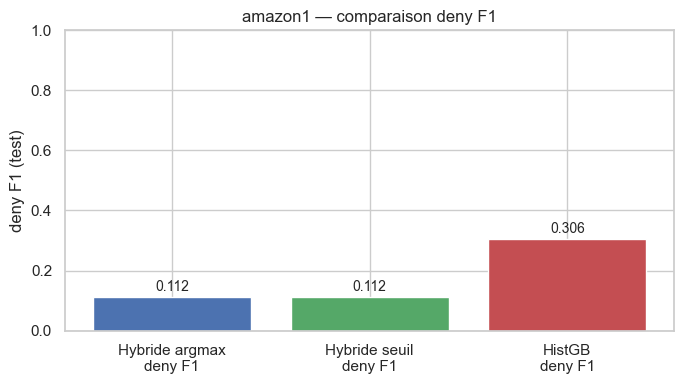

In [ ]:
if last_summary is None:
    raise RuntimeError("Exécutez d'abord la cellule d'entraînement.")

metrics = {
    "Hybride argmax\ndeny F1": last_summary["test_deny_f1"],
    "Hybride seuil\ndeny F1": last_summary["test_deny_f1_tuned"],
    "HistGB\ndeny F1": last_summary["sklearn_baseline"]["test_deny_f1_tuned"],
}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics.keys(), metrics.values(), color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("deny F1 (test)")
ax.set_title(f"{last_summary['dataset']} — comparaison deny F1")
ax.set_ylim(0, 1)
for b, v in zip(bars, metrics.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## Règles extraites (top 5)

In [ ]:
if last_summary is None:
    raise RuntimeError("Exécutez d'abord la cellule d'entraînement.")

for i, rule in enumerate(last_summary.get("rules_top10", [])[:5], start=1):
    print(f"Règle {i}: {format_rule(rule)}")

Règle 1: IF oh_176=+1 AND oh_429=-1 AND oh_324=-1 AND oh_50=-1 THEN deny (score=0.995)
Règle 2: IF oh_18=+1 AND oh_405=-1 AND oh_227=-1 AND oh_317=+1 THEN deny (score=0.974)
Règle 3: IF oh_89=-1 AND oh_381=-1 AND oh_478=-1 AND oh_305=-1 THEN deny (score=0.974)
Règle 4: IF oh_429=+1 AND oh_251=+1 AND oh_298=+1 AND oh_451=+1 THEN grant (score=0.969)
Règle 5: IF oh_507=-1 AND oh_472=-1 AND oh_99=+1 AND oh_287=-1 THEN deny (score=0.967)


## Exemple contrefactuel

In [ ]:
if last_summary is None:
    raise RuntimeError("Exécutez d'abord la cellule d'entraînement.")

cf = last_summary.get("cf_example", {})
print(json.dumps(cf, indent=2, ensure_ascii=False, default=str))

{
  "y_true": 1,
  "y_pred_orig": 0,
  "y_target": 0,
  "y_target_name": "deny",
  "y_pred_cf": 0,
  "valid": true,
  "n_flips": 251,
  "flips": [
    {
      "feature": "oh_1",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_4",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_11",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_13",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_14",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_15",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_17",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_18",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_21",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_24",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_28",
      "from": 1,
      "to": -1
    },
    {
      "feature": "oh_30",
      "from": 1,
      "to": -1
    }
  ]


## (Optionnel) Comparer bean / one-hot / quantile — epochs réduits

Test rapide des trois pipelines sur **un seul** jeu (`COMPARE_ENCODINGS = True`).

In [ ]:
COMPARE_ENCODINGS = False  # passez à True pour lancer
COMPARE_EPOCHS = 10

if COMPARE_ENCODINGS:
    cmp_rows = []
    for enc in ("bean", "onehot", "quantile"):
        s = train_amazon(
            DATASET_NAME,
            by_name[DATASET_NAME],
            encoding=enc,
            max_features=max_feat,
            epochs=COMPARE_EPOCHS,
            deny_oversample=max(1, DENY_OVERSAMPLE),
            save_dir=None,
            device=str(DEVICE),
            verbose=True,
        )
        cmp_rows.append(summary_row(s))
    display(pd.DataFrame(cmp_rows).round(4))
else:
    print("COMPARE_ENCODINGS=False — rien à faire.")

COMPARE_ENCODINGS=False — rien à faire.
